## Clinical Analytics 101 — Milestone 10

This tutorial series teaches **time-series SQL**, **CTEs** and **window
functions** the way analytics happens in a real organisation: someone asks a
*business question*, and you shape the data to answer it.

| Notebook | You will learn | Business questions |
|---|---|---|
| **Beginner** | JOINs, `date_trunc` time buckets, CTEs | Who is on the ward? Build the hourly handoff report. Flag the patient who needs attention at 04:00. |
| **Intermediate** | `LAG`/`LEAD`, moving averages, `RANK`/`NTILE` | When did the deterioration start? Is that spike real or device noise? Where does a reading sit in its patient's distribution? |
| **Advanced** | gap-and-islands episodes, sessionization, truth audits | How many *distinct* episodes? How do hundreds of alarm ticks become 2 alarm events? Can we trust the monitor? |

### How a lesson works

Every lesson is one heavily-commented SQL file in `sql/dql/<tier>/`. In each
lesson you read the business question, **read the SQL file** (it is printed),
**run it against the live Trino lakehouse**, read the answer, and see it on a
chart. With the compose stack down, the lesson cells fall back to the
pre-rendered parquet snapshots in `datasets/m10/lessons/`.

### The dataset

A tiny ward simulated by this repo (5-second telemetry through the Milestone 8
device layer):

| Patient | MRN | Story | Admitted | Monitored |
|---|---|---|---|---|
| **Naomi Brooks** | MRN-000101 | Desaturation (hypoxemia) | 00:00 | 6 h |
| **Cole Freeman** | MRN-000102 | Tachycardia | 00:30 | 5 h |
| **Ivy Watson** | MRN-000103 | Stable control | 01:00 | 3 h |

Patient demographics + admissions live in **MySQL** (`mysql.clinical`), the
observed vitals in the **Iceberg lakehouse** (`lake.lakehouse.vitals`), and
the exact simulated physiology in `lake.lakehouse.vitals_truth` (used in the
advanced notebook). `Ava Chen` and `Marcus Lee` are two legacy patients left
from earlier milestones — a gift, because real databases always contain older,
messier history.

> Rebuild or check this dataset anytime with
> `uv run python scripts/generate_m10_dataset.py`.


In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from healthcare_timeseries_lab.tutorials import (
    Lesson,
    load_lesson_sql,
    run_lesson,
    ward_names,
)

WARD = ward_names()
NAOMI = "55555555-5555-5555-5555-555555555555"
COLE = "66666666-6666-6666-6666-666666666666"
IVY = "77777777-7777-7777-7777-777777777777"


def lesson(stem: str) -> Lesson:
    tier = {"b": "beginner", "i": "intermediate", "a": "advanced"}[stem[0]]
    return Lesson(tier=tier, stem=stem)


def show_sql(stem: str) -> None:
    print(load_lesson_sql(lesson(stem)))


def tz_free(series: pd.Series) -> pd.Series:
    values = pd.to_datetime(series)
    if values.dt.tz is None:
        values = values.dt.tz_localize("UTC")
    return values.dt.tz_convert("UTC").dt.tz_localize(None)


pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (11, 4.2)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


# Beginner — know your ward

Three questions, each adding one skill:

* **B1** INNER JOIN — "who was on the ward on January 1st?"
* **B2** time bucketing + a CTE — "build the hourly handoff report."
* **B3** aggregate-then-filter + LEFT JOIN — "which patient needs attention at 04:00?"

Nail these and you can answer most "give me a summary" asks in any
organisation — the hard part was never the keyword, it was shaping the data.


### B1 — "Who was on the ward on January 1st?"

The charge nurse wants one list of every patient admitted that day: names,
MRNs, demographics and each admission window.

*What this teaches:* reading tables, an **INNER JOIN** between `patients` and
`encounters` in the same MySQL catalog, and a stable `ORDER BY`.

**Run the lesson** — first read its SQL, then execute it:


**1. Read the SQL for `b1_ward_census`** — the file comments explain the business question and how the query is assembled, piece by piece.

In [2]:
show_sql("b1_ward_census")

-- ============================================================================
-- Lesson B1 — "Who was on the ward on January 1st?"
--
-- Business question
--   The charge nurse wants a list of every patient who was admitted to the
--   ward on 2026-01-01, with name, MRN, demographics and their admission /
--   discharge window.
--
-- Concept taught
--   * Reading a table (SELECT from mysql.clinical)
--   * INNER JOIN across two tables in the SAME catalog (patients <-> encounters)
--   * ORDER BY for a stable, readable result
--
-- Why INNER JOIN?
--   We only want rows that exist in BOTH tables. A patient row without a
--   matching encounter row disappears, and an encounter without a patient
--   row disappears too. (Lesson B3 demonstrates LEFT JOIN, which is what you
--   reach for when you want to KEEP the patient row anyway.)
--
-- The two MRN-0000xx patients were created in Milestone 5; the three
-- MRN-0001xx patients (Naomi, Cole, Ivy) are this milestone's ward.
-- ===========

**2. Run it against the lakehouse.**

In [3]:
df = run_lesson(lesson("b1_ward_census"))
display(df)

,full_name,mrn,age,sex,admitted_at,ended_at,status
0,Ava Chen,MRN-000001,45,female,2026-01-01 00:00:00,2026-01-01 00:01:00,COMPLETED
1,Naomi Brooks,MRN-000101,52,female,2026-01-01 00:00:00,NaT,ACTIVE
2,Marcus Lee,MRN-000002,61,male,2026-01-01 00:30:00,2026-01-01 01:30:00,COMPLETED
3,Cole Freeman,MRN-000102,68,male,2026-01-01 00:30:00,2026-01-01 05:30:00,COMPLETED
4,Ivy Watson,MRN-000103,47,female,2026-01-01 01:00:00,2026-01-01 04:00:00,COMPLETED


**Reading the result.** Five rows:

* `Ava Chen` and `Marcus Lee` are the **legacy** Milestone 5 patients — their
  encounters are `COMPLETED`.
* Naomi, Cole and Ivy are this episode's ward. Naomi is `ACTIVE` with `NULL`
  in `ended_at`: she is *still admitted*. A `NULL` discharge time is
  information, not an error.

An **INNER JOIN** keeps only rows present on both sides — a patient without an
encounter vanishes. That is what we want here, and exactly what we
deliberately invert in B3.


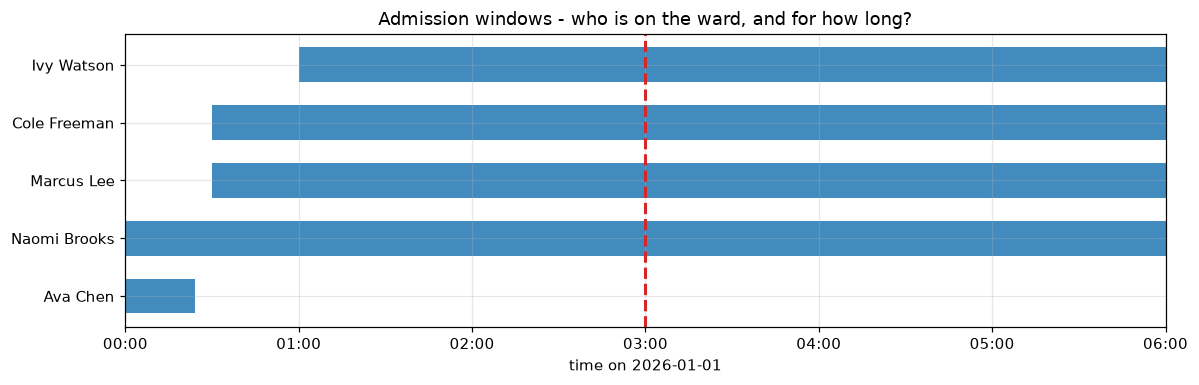

In [4]:
gantt = run_lesson(lesson("b1_ward_census")).copy()
start = tz_free(gantt["admitted_at"])
end = tz_free(gantt["ended_at"]).fillna(pd.Timestamp("2026-01-01 06:00:00"))

fig, ax = plt.subplots(figsize=(11, 3.6))
ordered = gantt.sort_values("admitted_at").reset_index(drop=True)
for i in range(len(ordered)):
    hours = (end.iloc[i] - start.iloc[i]).total_seconds() / 3600
    ax.barh(i, hours, left=start.iloc[i], height=0.6, color="#1f77b4", alpha=0.85)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(ordered["full_name"])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("time on 2026-01-01")
ax.set_title("Admission windows - who is on the ward, and for how long?")
ax.axvline(pd.Timestamp("2026-01-01 03:00:00"), color="#d62728", ls="--", lw=2)
ax.set_xlim(pd.Timestamp("2026-01-01 00:00:00"), pd.Timestamp("2026-01-01 06:00:00"))
plt.tight_layout()
plt.show()


**Your turn:**

1. Add `WHERE e.status = 'ACTIVE'` to B1 — who is currently admitted?
2. Add `WHERE p.age >= 50` — patients over 50.
3. Temporarily swap the join to a `LEFT JOIN` and watch Ava/Marcus change —
   you'll understand the difference fully by B3.

### B2 — "Build the hourly handoff report"

For every monitored patient, what did each vital average in each clock-hour?
This is the ward's shift-change handoff sheet.

*What this teaches:* the heart of time-series SQL — **`date_trunc('hour', ...)`**
buckets timestamps into clock-hours (change the unit and you have every other
periodic report), `GROUP BY patient + hour` with `AVG()` per vital, a **CTE**
(`WITH hourly AS (...)`) so the final SELECT is a clean read, and a
**cross-catalog JOIN** (vitals in `lake`, demographics in `mysql`).


**1. Read the SQL for `b2_hourly_handoff`** — the file comments explain the business question and how the query is assembled, piece by piece.

In [5]:
show_sql("b2_hourly_handoff")

-- ============================================================================
-- Lesson B2 — "Build the hourly handoff summary"
--
-- Business question
--   At shift change the oncoming nurse asks: "for every monitored patient,
--   what did each vital look like on average every hour?" The summary is the
--   handoff sheet: one row per patient per clock-hour.
--
-- Concepts taught
--   * Binning time with date_trunc('hour', timestamp) -- the bread and butter
--     of every time-series analysis
--   * GROUP BY patient + hour, with AVG() per vital
--   * ROUND() to keep the report readable
--   * A Common Table Expression (WITH hourly AS (...)) so the final SELECT is
--     a clean reading of an already-shaped table
--   * A second, cross-catalog JOIN now that the vitals live in a different
--     catalog (lake.lakehouse.vitals) than the demographics (mysql.clinical)
--
-- Read it top-down: WITH builds the "hourly" table, the main SELECT joins
-- it back to patient names and sorts it.

**2. Run it against the lakehouse.**

In [6]:
df = run_lesson(lesson("b2_hourly_handoff"))
display(df)

,shift_hour,full_name,avg_heart_rate,avg_spo2,avg_respiration,avg_temperature,readings
0,2026-01-01 00:00:00+00:00,Cole Freeman,84.5,97.0,17.0,37.10,358
1,2026-01-01 00:00:00+00:00,Naomi Brooks,76.1,99.0,15.0,36.92,717
2,2026-01-01 01:00:00+00:00,Cole Freeman,86.6,97.0,17.0,37.09,718
3,2026-01-01 01:00:00+00:00,Ivy Watson,62.1,99.0,12.0,36.71,717
4,2026-01-01 01:00:00+00:00,Naomi Brooks,76.0,99.0,14.9,36.91,716
5,2026-01-01 02:00:00+00:00,Cole Freeman,115.8,97.0,17.1,37.09,716
6,2026-01-01 02:00:00+00:00,Ivy Watson,62.0,99.0,12.1,36.71,716
7,2026-01-01 02:00:00+00:00,Naomi Brooks,80.7,94.4,17.6,36.90,718
8,2026-01-01 03:00:00+00:00,Cole Freeman,119.8,97.0,17.1,37.10,716
9,2026-01-01 03:00:00+00:00,Ivy Watson,62.1,99.0,12.1,36.71,718


**Reading the result.** 17 rows — and the naive guess is 16 (Naomi 6 hours +
Cole 6 + Ivy 4). The 17th row is Naomi's **06:00 bucket with a single
reading**: her telemetry stops at exactly `06:00:00` and `date_trunc` buckets
that boundary event into the *next* hour. Boundary events are a fact of life —
a good analyst spots and handles them deliberately.

The `avg_spo2` column carries the story: Naomi's hourly average dives to ~89 in
the 02:00 and 03:00 buckets while Cole (97) and Ivy (99) never waver.


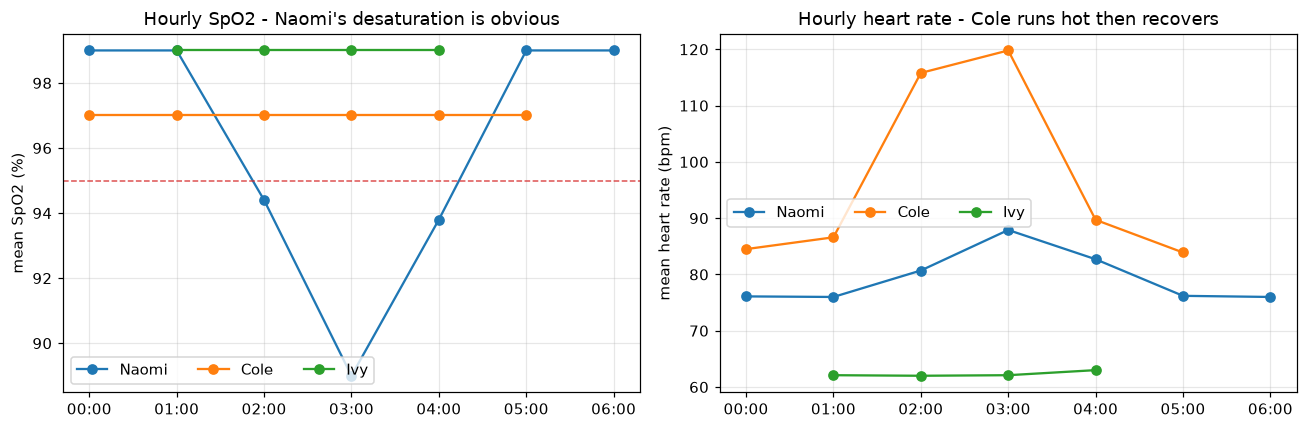

In [7]:
handoff = run_lesson(lesson("b2_hourly_handoff")).copy()
handoff["hour"] = tz_free(handoff["shift_hour"])

fig, (ax_spo2, ax_hr) = plt.subplots(1, 2, figsize=(12, 4))
for name in WARD.values():
    one = handoff[handoff["full_name"] == name].sort_values("hour")
    label = name.split()[0]
    ax_spo2.plot(one["hour"], one["avg_spo2"], marker="o", label=label)
    ax_hr.plot(one["hour"], one["avg_heart_rate"], marker="o", label=label)

ax_spo2.axhline(95, color="#d62728", ls="--", lw=1, alpha=0.8)
ax_spo2.set_ylabel("mean SpO2 (%)")
ax_spo2.set_title("Hourly SpO2 - Naomi's desaturation is obvious")
ax_spo2.legend(ncol=3)

ax_hr.set_ylabel("mean heart rate (bpm)")
ax_hr.set_title("Hourly heart rate - Cole runs hot then recovers")
ax_hr.legend(ncol=3)

for axis in (ax_spo2, ax_hr):
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()


**Your turn:**

1. Change `date_trunc('hour', ...)` to `'minute'` in B2 and re-run — the
   report inflates ~60x. That knob is your sampling rate.
2. Confirm Ivy has ~720 readings/hour (60 min x 12 ticks, minus dropouts).
3. Extend the CTE with the per-hour *max minus min* SpO2 spread — the next
   notebook computes the same idea with window functions and throws in `LAG`
   for free.

### B3 — "Which patient needs attention at 04:00?"

Which monitored patients spent the previous hour (03:00-04:00) with an
**average SpO2 below 95%**?

*What this teaches:* you cannot put `AVG()` in a `WHERE` clause — aggregates
are computed first, filtered after (we shape the aggregate in a CTE and filter
in the outer query), and **LEFT JOIN vs INNER JOIN**: Marcus Lee exists in the
clinical store but has *no telemetry at all*. An INNER JOIN would quietly hide
him; a LEFT JOIN keeps the row and marks the missing data `NULL` — and that
absence is itself the finding.


**1. Read the SQL for `b3_flag_attention`** — the file comments explain the business question and how the query is assembled, piece by piece.

In [8]:
show_sql("b3_flag_attention")

-- ============================================================================
-- Lesson B3 — "Flag the patient who needs attention overnight"
--
-- Business question
--   It is 04:00 on the ward. Which monitored patients spent the previous
--   hour (03:00-04:00) with an average SpO2 below 95%? Everything we know
--   says one of them was desaturating during the night.
--
-- Concepts taught
--   * Filtering on a time window (BETWEEN ... AND ...)
--   * Aggregating before filtering: AVG() can NOT go in WHERE, so we compute
--     it first (in a CTE) and then apply HAVING / WHERE-on-the-aggregate
--   * A LEFT JOIN, to keep patients even when they have no telemetry -- see
--     the difference between INNER JOIN (B1) and LEFT JOIN here
--
-- Note: HAVING is how you filter a grouped aggregate directly; we use the
-- CTE + WHERE pattern to keep the logic readable and to make the report
-- columns available to the outer query.
--
-- The LEFT JOIN is the key learning this lesson: Marcus Le

**2. Run it against the lakehouse.**

In [9]:
df = run_lesson(lesson("b3_flag_attention"))
display(df)

,full_name,mrn,avg_spo2,readings,status
0,Ava Chen,MRN-000001,88.0,1440.0,COMPLETED
1,Naomi Brooks,MRN-000101,89.0,717.0,ACTIVE
2,Cole Freeman,MRN-000102,97.0,716.0,COMPLETED
3,Ivy Watson,MRN-000103,99.0,718.0,COMPLETED
4,Marcus Lee,MRN-000002,NaN,NaN,COMPLETED


**Reading the result.** Two patients sit below 95%:

* **Naomi Brooks — avg 89** across 03:00-04:00. That's the desaturation. Cole
  (97) and Ivy (99) are fine.
* **Ava Chen — avg 88.** The *legacy* patient's older trace also dipped. Real
  organisations accumulate messy history; a good analyst asks "same episode or
  a different run?" before reporting it as today's event.
* **Marcus Lee — `NULL`.** Not a missing value — *no measurements exist*. The
  LEFT JOIN preserved the row so the nurse sees "patient known, telemetry
  absent". That distinction is why LEFT JOIN exists.


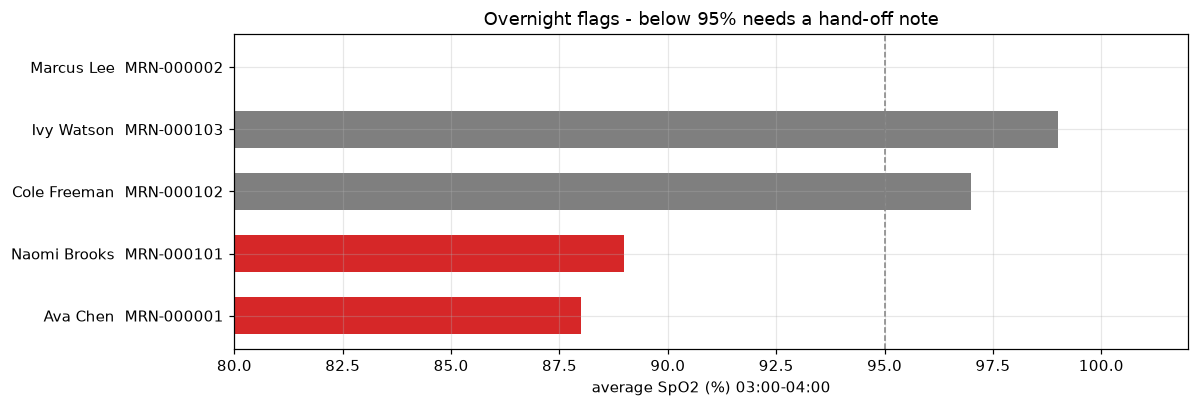

In [10]:
flags = run_lesson(lesson("b3_flag_attention")).copy()
flags = flags.sort_values("avg_spo2", na_position="last").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 3.8))
colors = ["#d62728" if (value is not None and value < 95) else "#7f7f7f"
          for value in flags["avg_spo2"]]
ax.barh(range(len(flags)), flags["avg_spo2"].fillna(0), color=colors, height=0.6)
ax.set_yticks(range(len(flags)))
ax.set_yticklabels(flags["full_name"] + "  " + flags["mrn"].fillna(""))
ax.axvline(95, color="grey", ls="--", lw=1)
ax.set_xlabel("average SpO2 (%) 03:00-04:00")
ax.set_title("Overnight flags - below 95% needs a hand-off note")
ax.set_xlim(80, 102)
plt.tight_layout()
plt.show()


**Your turn:**

1. Swap the LEFT JOIN to an INNER JOIN in
   `sql/dql/beginner/b3_flag_attention.sql` and re-run — Marcus disappears.
   That is the entire lesson, hands-on.
2. Move the threshold to `97` and watch Cole get flagged. Thresholds are a
   business decision, not a math law.
3. What if a patient had only *one* reading in the hour? Should that count as
   an "average"?

## End of the beginner course

You can now shape a query, join two tables, bucket time, compose with CTEs, and
aggregate-then-filter — a complete skill set for summary reports.

Before the intermediate notebook, look at Naomi's raw SpO2 curve in
`lake.lakehouse.vitals` and notice how twitchy it is. That noise is exactly
what the next three lessons are about.
